# Neural Network Basics

A **Neural Network** is a machine learning model inspired by the structure of the human brain. Put simply: neural networks minimize error just like `scipy.optimize.minimize`. As this occurs, we say **learns patterns from data** that can then be used for a number of tasks. For example, data classification, data generation, and more. For this class, we will focus on classification of data.

### Mathematical Background
First, we'll cover the background of the networks we will deal with. Firstly, we will take a dataset and vectorize it. Then, we send it to the neurons.
#### Neurons

Designed to mimic physical neurons, this most basic neural network object does the following:
1. Receives inputs in the form of vectors
2. Weights the input
3. Applies some function
4. Outputs the new re-weighted values to another set of neurons

We collect sets of neurons into *layers*. The first layer is the *input layer*, the last is the *output layer*, and every layer in between is a *hidden layer*.

#### Forward Passes

In order for the neural network to "learn", it first needs to predict. Testing whether these outputs are correct will come later. We will input some data set and the following will occur:
1. Vector inputs enter the network
2. Each layer reweights inputs then applies "activation functions" to generate outputs for the next layer
3. At the output layer, predictions of classes are produced

For example, if I input a dataset like `iris` that has information on certain flower properties, then we output the probability that a certain flower is a specific species.


Without activation functions, neural networks behave like linear models. We want more complicated models. Common activation functions include:
1. Sigmoid $\sigma(x) = 1 / (1 + e^{-x})$
2. ReLU $ f(x) = \max\{0, x\}$
3. Hyperbolic tangent $\tanh(x)$


#### Backward Passes

Now that we have a set of predictions we want to know how right or wrong we were. First, we must define what right and wrong are in this context. This is where *loss functions* come in. The loss function measures prediction error (how well the model is performing). Common loss functions:
1. Mean Squared Error (Regression) $MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$
2. Binary Crossentropy $ L = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i)\right] $
3. Categorical Crossentropy $ L =-\sum_{i=1}^{C}y_i\log(\hat{y}_i)$

Once we have this error, we attribute certain amounts of error to individual neurons. Weights are updated by performing gradient descent:
```
new_weight = old_weight - learning_rate x gradient
```
where `learning_rate` is a parameter controlling how much effect the gradient has on reweighting.

The process works as follows:
```
Prediction -> Compute Error -> Compute Gradients -> Update Weights
```



In [1]:
# preliminaries

import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt



### Full Working Example
Let's start with some random data $X$ with its true labels $Y$.

In [11]:

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

Y = np.array([0,1,0,1])


Now we can create a neural network:

In [12]:
model = Sequential([
    Dense(4, activation="relu", input_shape=(2,)),
    Dense(1, activation="sigmoid")
])

c:\Users\garre\miniconda3\envs\jbook\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


We will define how the backpropagation will occur:
- Optimizer: Adam
- Loss: Binary Crossentropy

And what should be tracked:
- Metric: Accuracy


In [13]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Training consists of:
- Forward propagation
- Loss calculation
- Backpropagation
- Weight updates

In [18]:
model.fit(
    X,
    Y,
    epochs=1000,
    verbose=False
)

We can see how well our neural network performs on the classification:

In [19]:
loss, accuracy = model.evaluate(X, Y)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.0820
Accuracy: 1.0


What the neural network is learning is a boundary. What's going on visually is like this:

Text(0.5, 1.0, 'Basic Classification Task')

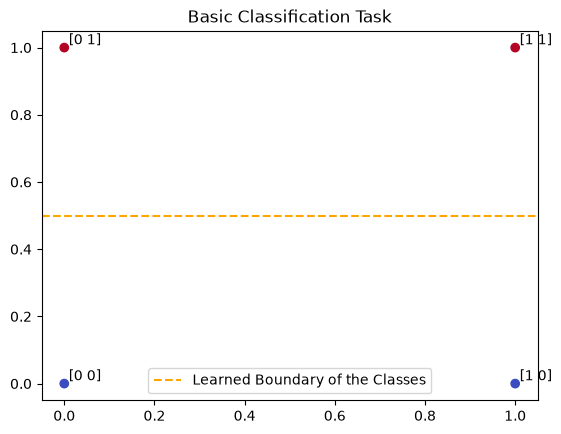

In [41]:
plt.scatter(X[:,0], X[:,1], # data 
            c=Y, # true labels for data
            cmap='coolwarm')

for i in range(len(X)):
    plt.annotate(X[i], (X[i, 0]+.01, X[i,1]+.01))
plt.axhline(.5, c='orange', linestyle='--',label='Learned Boundary of the Classes')
plt.legend()
plt.title('Basic Classification Task')

And after training, we can make predictions for other vectors!

In [61]:
newdata = np.array([[1,2],
                    [-1,-1],
                    [.25, .6],
                    [.15, .3]])
prediction = model.predict(newdata)
classes = [int(i[0]) for i in prediction<.5]

print(classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
[0, 1, 0, 1]


Text(0.5, 1.0, 'Predicted Classification')

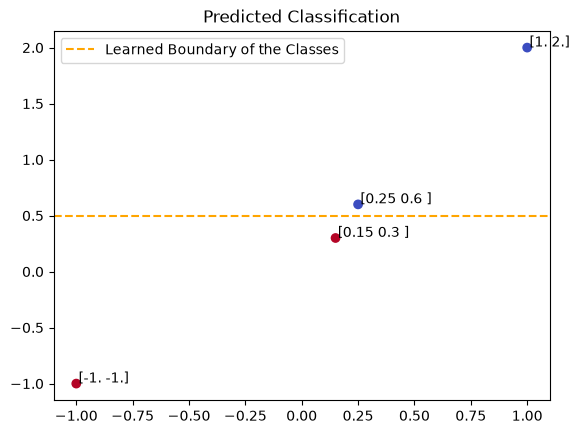

In [62]:
plt.scatter(newdata[:,0], newdata[:,1], # data 
            c=classes, # true labels for data
            cmap='coolwarm')

for i in range(len(newdata)):
    plt.annotate(newdata[i], (newdata[i, 0]+.01, newdata[i,1]+.01))
plt.axhline(.5, c='orange', linestyle='--',label='Learned Boundary of the Classes')
plt.legend()
plt.title('Predicted Classification')

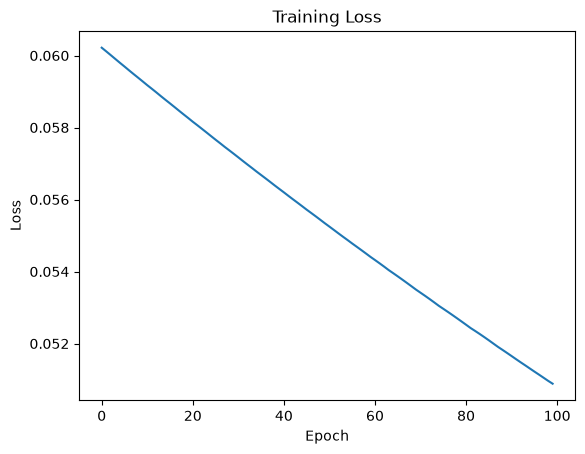

In [ ]:
network = model.fit(
    X,
    Y,
    epochs=100,
    verbose=False
)

plt.plot(network.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Advantages of Neural Networks
- Can learn complex relationships
- Typically high accuracy
- Works well with large datasets
- Can solve image, text, and audio problems

### Limitations
- Requires significant training data
- Computationally expensive
- Can overfit
- Often difficult to interpret

### Ethical Considerations
- This is probabilistic in nature. Inference should keep this in mind.
- The human supervision should ensure these networks operate appropriately. 

### Lab Problems

---

1. Create a neural network with:
- 2 input features
- 8 hidden neurons
- ReLU activation
- 1 sigmoid output neuron

---

2. Create your own dataset and train the model for:

- 50 epochs
- 100 epochs
- 300 epochs

Compare the results.

---

3. Replace the optimizer:

```python
optimizer="sgd"
```

Compare it with:

```python
optimizer="adam"
```

---

4. Create a neural network to classify flowers in the Iris dataset by species:
- Input layer
- One hidden layer
- Three output neurons
- Softmax activation

### Lab Key*

---

1.

---

2.

---

3.